In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special
from scipy.special import wofz

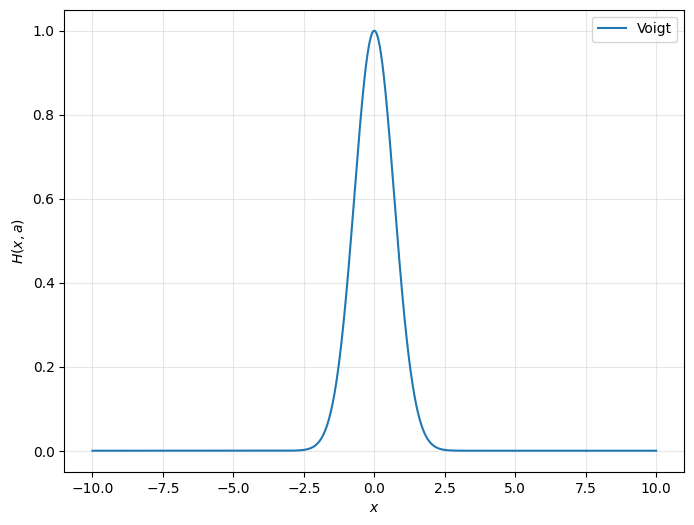

In [3]:
def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s

x_arr = np.linspace(-10, 10, 2000)
# a_values = [1e-3, 1e-2, 1e-1, 1.0]

gamma_K= 2.65e8 # 1/ s 
Delnu = (50/cc_k) * 1.936410e15

a = gamma_K / (4*np.pi*Delnu)

plt.figure(figsize=(8, 6))
# for a in a_values:
plt.plot(x_arr, H_voigt_fast(x_arr, a),label='Voigt')

plt.xlabel(r"$x$")
plt.ylabel(r"$H(x,a)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
emu_e = 1.602e-19*3e9 # Electric charge : emu
m_e = 9.10938356e-28 # Electron Mass : g 

C_IV_gamma_H = 2.64e+8 
C_IV_gamma_K = 2.65e+8 
C_IV_f12_H   = 0.0952e0
C_IV_f12_K   = 0.190e0
CIV_nu_K = 1.936410e15
CIV_nu_H = 1.933182e15


C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s


1.14e+14


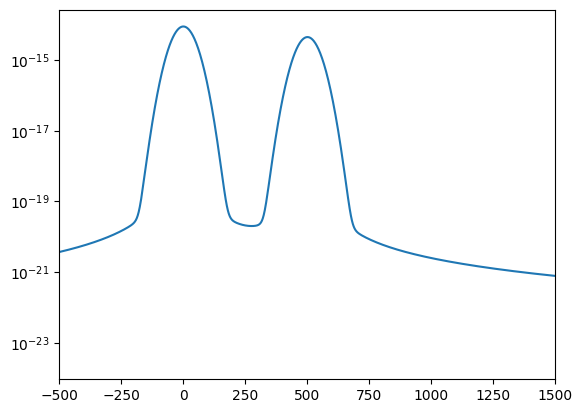

In [18]:
nu = np.linspace(1.8e15,2.0e15,100000)

# emu_e = 1.602e-19*3e9 # Electric charge : emu
emu_e = 4.80320471257e-10
m_e = 9.10938356e-28 # Electron Mass : g 

C_IV_gamma_H = 2.64e+8 
C_IV_gamma_K = 2.65e+8 
C_IV_f12_H   = 0.0952e0
C_IV_f12_K   = 0.190e0
CIV_nu_K = 1.936410e15
CIV_nu_H = 1.933182e15


C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s


def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))


def cross_section(nu,v_th):
    sigma0 = (np.sqrt(np.pi)*emu_e**2) / (m_e*cc) 
    del_nu_K = ((v_th) / cc_k) * CIV_nu_K
    del_nu_H = ((v_th) / cc_k) * CIV_nu_H

    x_K = ((nu - CIV_nu_K ) / del_nu_K)
    x_H = ((nu - CIV_nu_H ) / del_nu_H)
    
    a_K = C_IV_gamma_K / (4*np.pi*del_nu_K)
    a_H = C_IV_gamma_H / (4*np.pi*del_nu_H)


    K_term = (C_IV_f12_K /  del_nu_K) * H_voigt_fast(x_K, a_K)
    H_term = (C_IV_f12_H /  del_nu_H) * H_voigt_fast(x_H, a_H)


    cross_sec = sigma0 * (K_term + H_term)

    return cross_sec

v_th = 50
cros = cross_section(nu,v_th)

Del_V = (CIV_nu_K/ nu -1)*cc_k

plt.plot(Del_V,cros)
plt.yscale('log')
plt.xlim(-500,1500)

print(f'{1 / cros.max():.2e}')


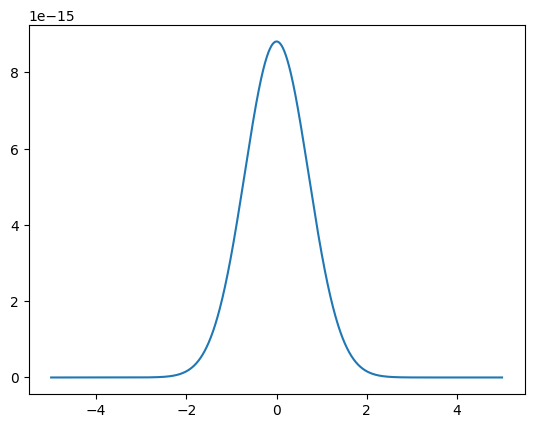

In [21]:
V_c = 250 # km/s ()
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k


K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
H_region = np.where((Del_V >= Vsep-V_c) & (Del_V <= Vsep + V_c))

delV_K,cs_K = Del_V[K_region], cros[K_region]
delV_H, cs_H  = Del_V[H_region], cros[H_region]

x_kk = delV_K / (-v_th) 
x_hh = (delV_H-Vsep) / (-v_th) 

plt.plot(x_kk,cs_K)


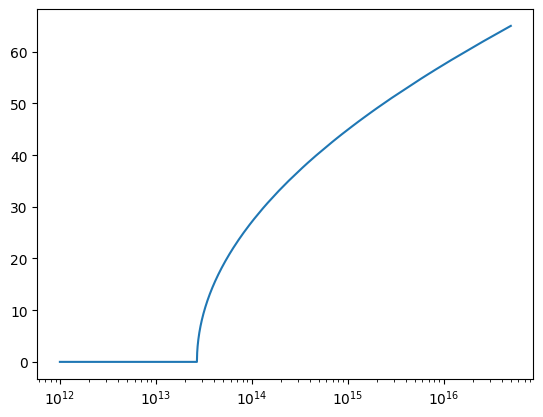

In [ ]:
NN = 5e3
C_iv_N = np.logspace(np.log10(1e12), np.log10(5e16), int(NN))

v_th = 11.8
cros = cross_section(nu,v_th)

Del_V = (CIV_nu_K/ nu -1)*cc_k



# plt.plot(x_kk,tau0)

tau_profile_K = C_iv_N[:, None] * cs_K

K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
H_region = np.where((Del_V >= Vsep-V_c) & (Del_V <= Vsep + V_c))

delV_K,cs_K = Del_V[K_region], cros[K_region]
delV_H, cs_H  = Del_V[H_region], cros[H_region]

x_kk = delV_K / (-v_th) 
x_hh = (delV_H-Vsep) / (-v_th)


x_esc = np.zeros(len(C_iv_N))
for ii in range(len(C_iv_N)):
    tau_i = tau_profile_K[ii, :]
    s = tau_i - 1.0

    # Find sign changes of (tau - 1) and linearly interpolate x where tau=1
    cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

    if cross_idx.size == 0:
        x_esc[ii] = 0.0
        continue

    x_candidates = []
    for jj in cross_idx:
        tau_a, tau_b = tau_i[jj], tau_i[jj + 1]
        x_a, x_b = x_kk[jj], x_kk[jj + 1]

        if tau_b == tau_a:
            continue

        x_cross = x_a + (1.0 - tau_a) * (x_b - x_a) / (tau_b - tau_a)
        x_candidates.append(x_cross)

    # Keep the maximum x (matches original idea of choosing the positive boundary)
    x_esc[ii] = max(x_candidates) if len(x_candidates) > 0 else 0.0

    del_lam_D = (v_th*1e5) / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_esc*del_lam_D + nu_0_K
    V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_esc*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

plt.plot(C_iv_N, V_del_peak)
plt.xscale('log')